In [1]:
# import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

c:\Users\samue\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
seed = 2724

### Import data

In [4]:
DF_PATH = "mod04_data/sample.csv"
df = pd.read_csv(DF_PATH)

### Separate data by independent (X) and dependent (y) variables

In [5]:
X = df[["income", "education_years", "zipcode_score"]]
y = df["target"]

### Split the data into a _training_ set (to build a model) and _test_ set (to validate a model)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

### Build a model on the training set

In [7]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=seed
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=2724)

### Use SHAP to explain the model on test data

In [8]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

 99%|===================| 1490/1500 [02:44<00:01]        

This will allow us to see which variables are most important to predicting the outcome.

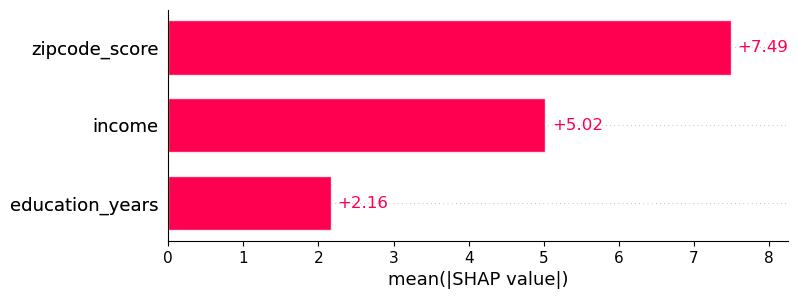

In [9]:
shap.plots.bar(shap_values)

### Import the `group` variable, which was **not** used in training this model.

In [ ]:
X_test_with_group = X_test.copy()
X_test_with_group["group"] = df.loc[X_test.index, "group"]

,income,education_years,zipcode_score,group
1080,40068.226998,12.394158,75.913372,0
3681,93627.698722,9.489185,56.188920,0
1874,67610.321570,13.463495,74.826917,0
979,79002.170820,12.913168,68.457626,0
3114,49710.043314,14.667801,71.521360,1
...,...,...,...,...
855,72687.619742,12.822737,77.612085,0
1060,71211.011639,16.117331,60.974301,1
3251,39972.157909,14.100833,68.475200,0
4067,69287.793196,14.871796,77.390844,0


### Look at the difference in SHAP values between the two groups across the variables used in the model.

In [11]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df["group"] = X_test_with_group["group"].values

shap_df.groupby("group").mean()

,income,education_years,zipcode_score
group,,,
0,1.086254,-0.170779,5.866534
1,1.020094,-0.192841,-6.859435


### Let's put `group` and `zipcode_score` in the same plot

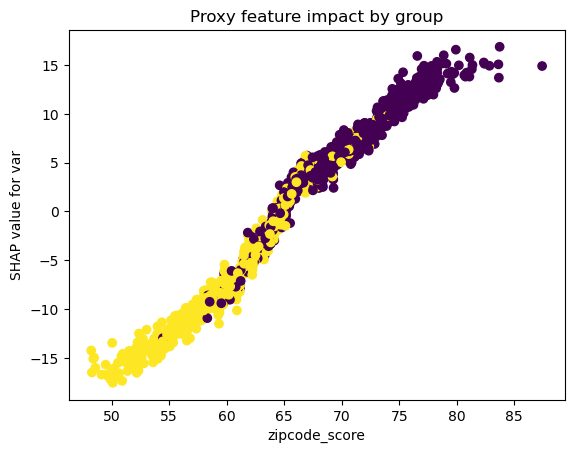

In [12]:
def plot_shap(var):
    # Extract SHAP values for the feature
    shap_var = shap_values[:, var].values

    # Plot the values of each group using different colors
    plt.figure()
    plt.scatter(
        X_test[var],
        shap_var,
        c=X_test_with_group["group"]
    )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for var")
    plt.title("Proxy feature impact by group")
    plt.show()

plot_shap("zipcode_score")

# Discussion Questions

### What is a _SHAP_ (or Shapley) value? 

a SHAP value is a measure of feature importance for a specific instance in the training set. In other words: for each row in our training set, we make a prediction, SHAP is a quantification for each feature, of the importance of the feature in making that prediction for that row.

### Suppose you built this model and then it is peer reviewed by another entity. If the reviewer asks whether you used the variable `group` in your model, what would your answer be?

Type your answer here

No. We imported group afterwards and didn't use it to train the model.

### If the reviewer asks whether the outcome of your model is correlated with `group`, what would your answer be?

I would say Yes. If group is zero, SHAP for our most important trained feature "zipcode_score" is strongly negative and if it is positive our SHAP for zipcode_score is strongly positive. This clearly shows that our models prediction is strongly influenced by group, and more than that, that zipcode_score and group are highly correlated.

### Construct a "proxy feature impact by group" plot for `income`. How is this plot different from the one for `zipcode_score`?

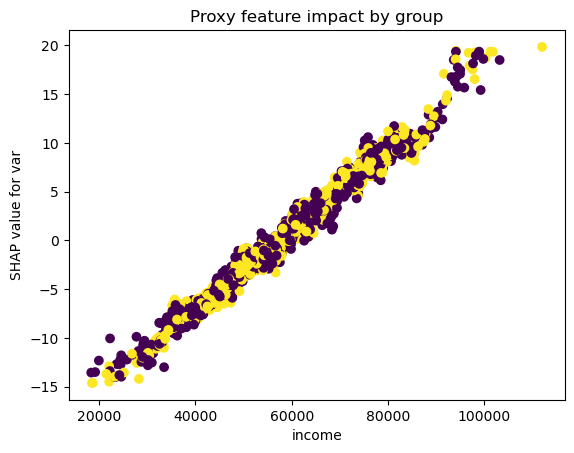

In [14]:
plot_shap("income")

The groups are completely mixed together. There is no correlation between group and income value. So the shap value for income appears to depend mainly on the magnitude of income rather than group category.

### If, instead, you were the **reviewer**, what other questions might you ask the person who built this model? Give at least two.

1. Do you believe this model type (RandomForest) shows potential and should it proceed to be tuned.
2. Should Education years be removed? it doesn't appear to be contributing very much based of the SHAP values.